# Lab 6
### Morphology

Skimage morphology operators' documentation:
https://scikit-image.org/docs/dev/api/skimage.morphology.html

In [246]:
from commonfunctions import *
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.color import rgb2gray
from skimage.morphology import binary_erosion, binary_dilation, binary_closing,skeletonize, thin, square, closing, rectangle as rect
from skimage.measure import find_contours
from skimage.draw import rectangle
from skimage.filters import threshold_otsu

# Show the figures / plots inside the notebook
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


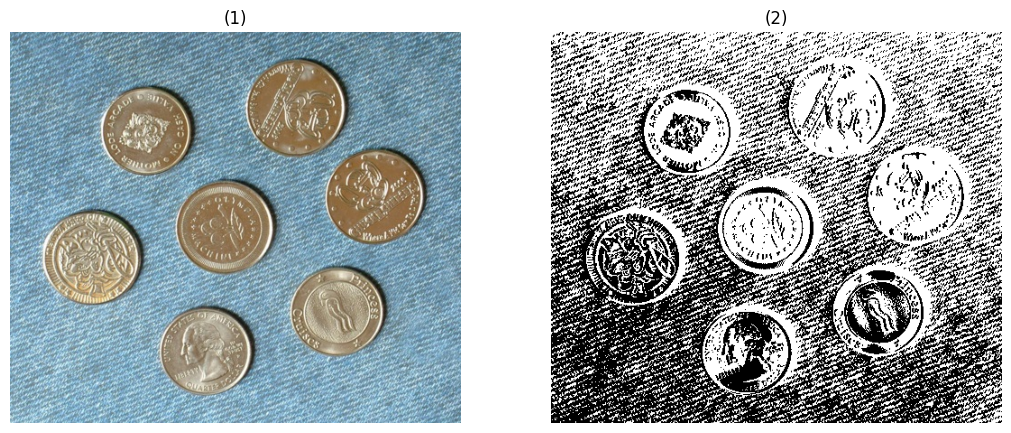

In [247]:
'''
1) Erosion / Dilation:
    - Load "coins.jpg" from the img folder
    - Convert the image to binary
    - Write 2 functions each applying 1 of the erosion/dilation algorithms (with adjustable square window size) manually to the binary image
    - Use Skimage's "binary_erosion" & "binary_dilation" & show the results
'''

img = io.imread('./img/coins.jpg')
img_gray = rgb2gray(img)
img_gray *= 255
thresh = threshold_otsu(img_gray)
binary_img = img_gray < thresh
show_images([img, binary_img])


In [248]:
def manual_erosion(image, kernel_size):
        
    radius_h = (kernel_size[0] - 1) // 2
    radius_w = (kernel_size[1] - 1) // 2
    
    padded_image = np.pad(image, pad_width=((radius_h, radius_h), (radius_w, radius_w)), mode='constant', constant_values=0)
    
    rows, cols = image.shape
    
    output_image = np.zeros_like(image, dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):
            
            window = padded_image[i : i + kernel_size[0], j : j + kernel_size[1]]
            output_image[i, j] = np.min(window)
            
    return output_image
    


In [249]:
def manual_dilation(image, kernel_size):

    radius_h = (kernel_size[0] - 1) // 2
    radius_w = (kernel_size[1] - 1) // 2

    padded_image = np.pad(image, pad_width=((radius_h, radius_h), (radius_w, radius_w)), mode='constant', constant_values=0)
    
    rows, cols = image.shape
    
    output_image = np.zeros_like(image, dtype=np.uint8)

    for i in range(rows):
        for j in range(cols):
            
            window = padded_image[i : i + kernel_size[0], j : j + kernel_size[1]]
            output_image[i, j] = np.max(window)
            
    return output_image

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4576\3195570606.py:1: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  er1 = binary_erosion(binary_img, footprint=square(3))
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4576\3195570606.py:2: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  di1 = binary_dilation(binary_img, footprint=square(2))


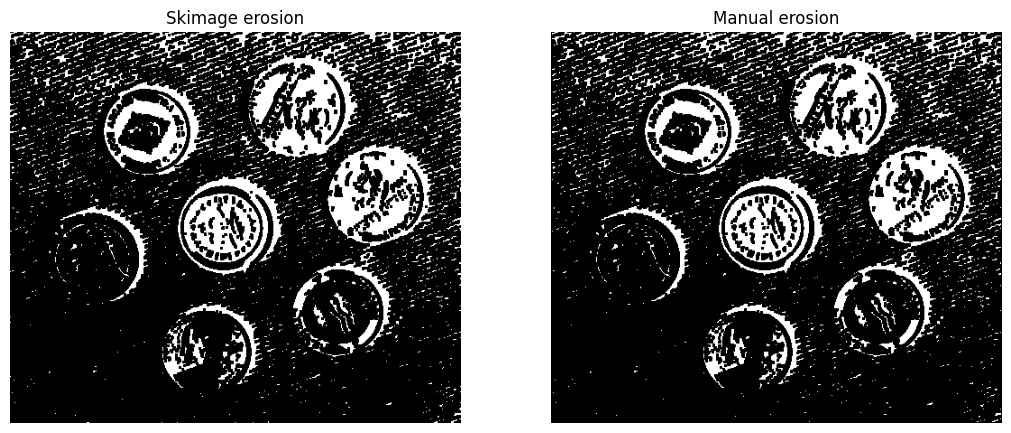

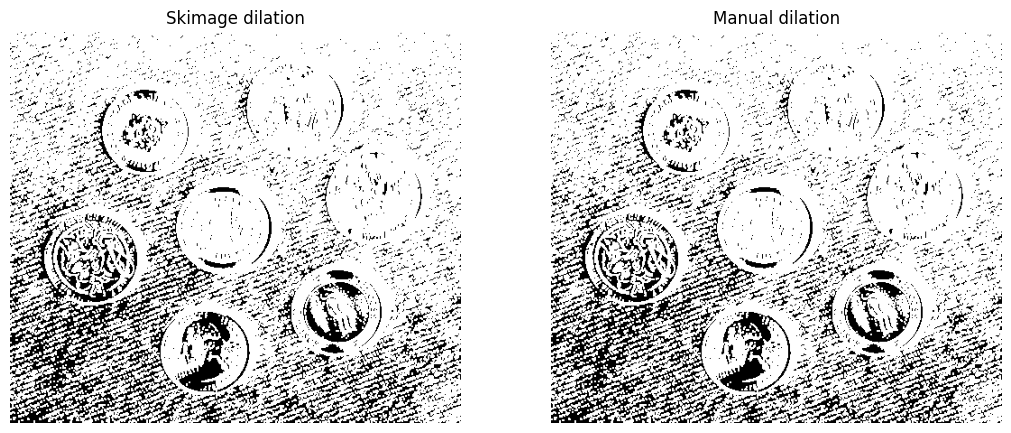

In [250]:
er1 = binary_erosion(binary_img, footprint=square(3))
di1 = binary_dilation(binary_img, footprint=square(2))
er2 = manual_erosion(binary_img, (3,3))
di2 = manual_dilation(binary_img, (2,2))

show_images([er1, er2], ['Skimage erosion', 'Manual erosion'])
show_images([di1, di2], ['Skimage dilation', 'Manual dilation'])

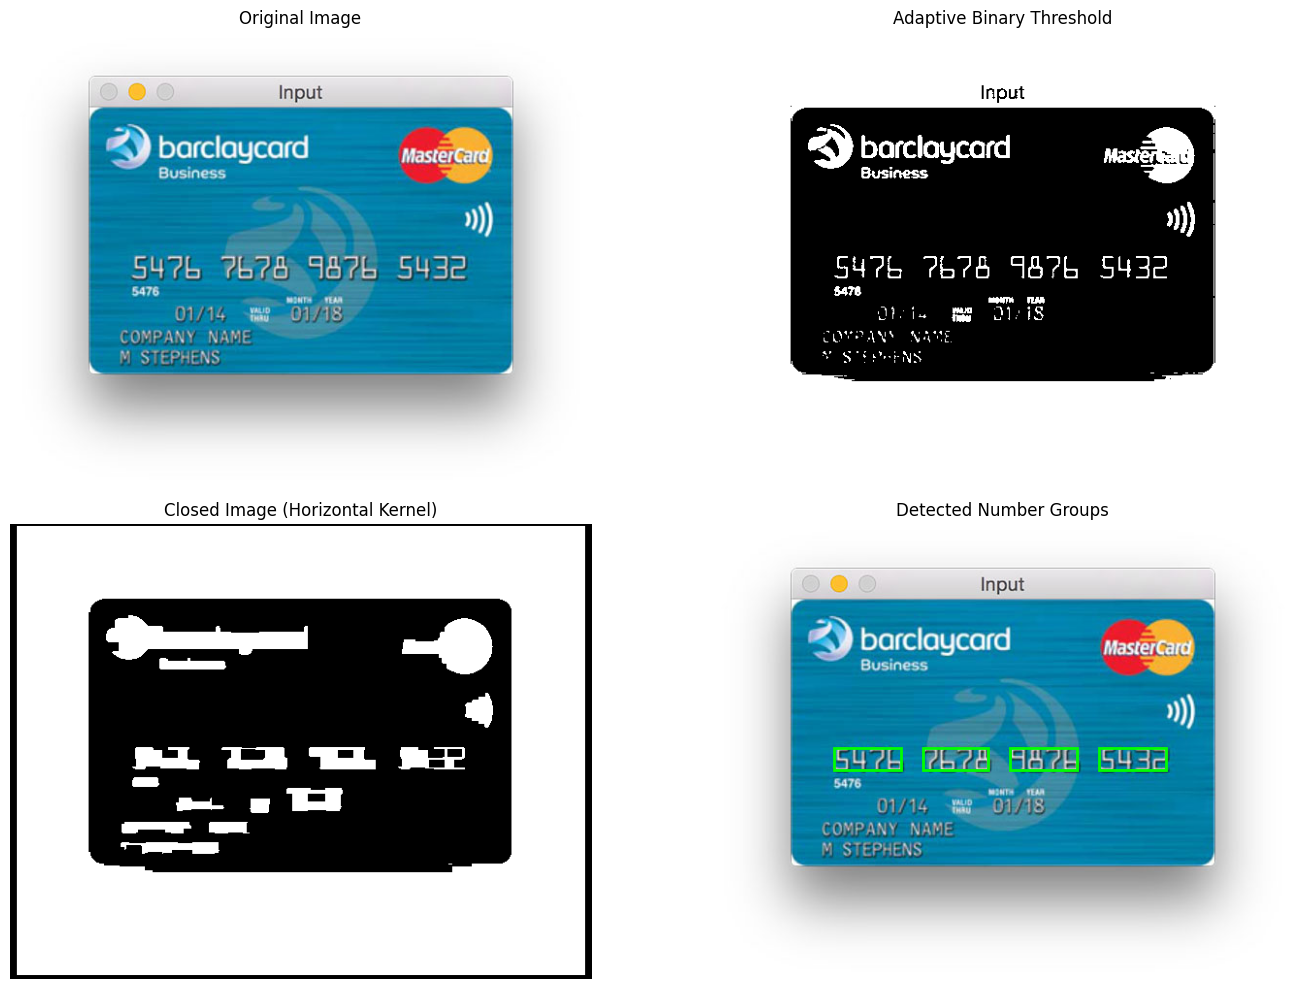

In [251]:
'''
2) Case Study: Credit Card Number Extraction
    - Load "card.jpg" from the img folder
    - Convert the image to binary by brightness thresholding maintaining the card number details for extraction
    - Use your erosion/dilation functions, or Skimage's functions only if you didn't implement them, to apply closing
        Note: The goal of this step is to join the card number into 4 sets of connected pixels
    - Use Skimage's "find_contours" to get the bounding boxes for the credit card's numbers by filtering on aspect ratio (between 2.5 & 3.5)
        Note: When using "find_contours(img, 0.8)" the o/p is a list of contours each having:
                - contour[:,0] being the Y values of the contour perimeter points
                - contour[:,1] being the X values of the contour perimeter points
'''

img_rgb = io.imread('./img/card.jpg')
img = rgb2gray(img_rgb)
img *= 255
img = img > 150 #thresholding to make it binary
closing_img = manual_erosion(manual_dilation(img,(8,15)), (8,15)) 


contours = find_contours(closing_img, 0.8)
    
found_boxes = []

for contour in contours:
    # Get Y (row) and X (col) coordinates
    y_coords = contour[:, 0]
    x_coords = contour[:, 1]
    
    # Calculate bounding box
    min_y, max_y = np.min(y_coords), np.max(y_coords)
    min_x, max_x = np.min(x_coords), np.max(x_coords)
    
    bbox_height = max_y - min_y
    bbox_width = max_x - min_x
    
    # Avoid division by zero
    if bbox_height > 0:
        aspect_ratio = bbox_width / bbox_height
        
        # Filter by the specified aspect ratio range and box height
        if 2.5 <= aspect_ratio <= 3.5 and 20 <= bbox_height <= 50:
            found_boxes.append((min_x, min_y, max_x, max_y))

fig, ax = plt.subplots(2, 2, figsize=(15, 10))
    
ax[0, 0].imshow(img_rgb)
ax[0, 0].set_title('Original Image')

ax[0, 1].imshow(img, cmap='gray')
ax[0, 1].set_title('Adaptive Binary Threshold')

ax[1, 0].imshow(closing_img, cmap='gray')
ax[1, 0].set_title('Closed Image (Horizontal Kernel)')

ax[1, 1].imshow(img_rgb)
ax[1, 1].set_title('Detected Number Groups')

for (min_x, min_y, max_x, max_y) in found_boxes:
    width = max_x - min_x
    height = max_y - min_y
    rect = patches.Rectangle((min_x, min_y), width, height, 
                                linewidth=2, edgecolor='lime', facecolor='none')
    ax[1, 1].add_patch(rect)

for a in ax.flat:
    a.axis('off')
    
plt.tight_layout()
plt.show()


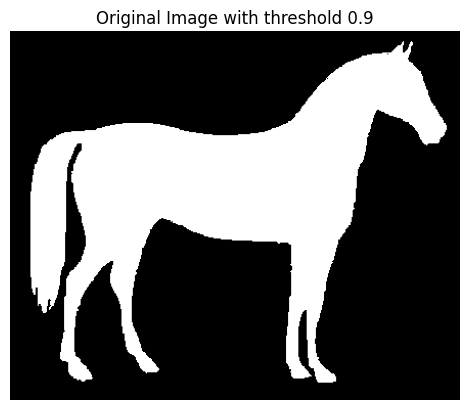

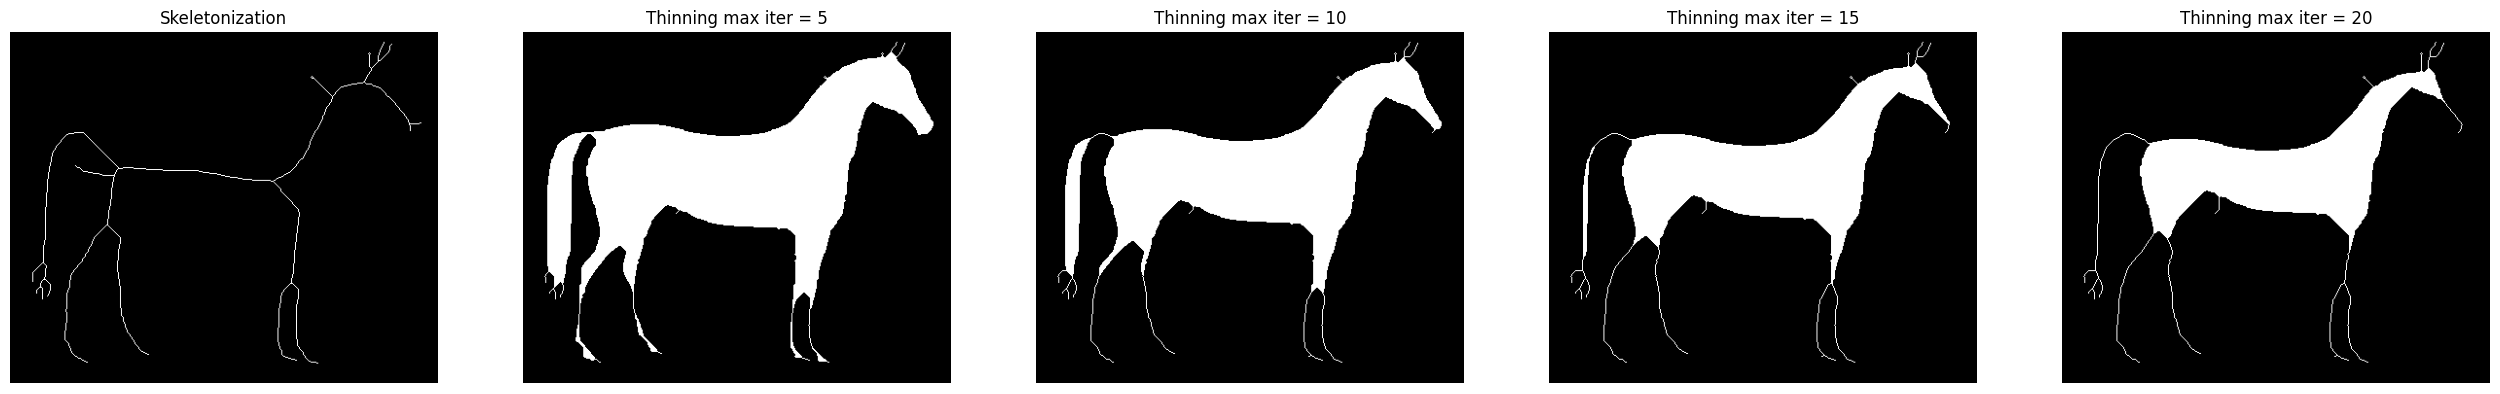

In [252]:
'''
3) Skeletonization:
    - Load "horse.jpg" from the img folder 
    - Use a binary threshold of 0.9 to remove invisible noise in the background
    - Use Skimage's "skeletonize(image)" to acquire the image's skeleton & show it
    - Use Skimage's "thin(image, max_iter)" with values of max_iter 5/10/15/20 & show it
'''

img = rgb2gray(io.imread('./img/horse.jpg'))
img = img > 0.9
show_images([img], ['Original Image with threshold 0.9'])
images = []
images.append(skeletonize(img))
for i in range(5,25,5):
    images.append(thin(img, i))

show_images(images, ['Skeletonization', 'Thinning max iter = 5', 'Thinning max iter = 10', 'Thinning max iter = 15', 'Thinning max iter = 20'])
